In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras


C:\Users\jaadt\AppData\Local\Temp\ipykernel_35784\2897261863.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


1. Using your fire dataset develop a method of labeling which pixels are associated with the fire (using the segmentation data set)
2. Develop a method that label which pixels in the Fire vs No Fire dataset have fire in them.


In [2]:
BATCH_SIZE = 32

image_train = tf.keras.utils.image_dataset_from_directory(
    "Images/",
    validation_split=0.2,
    subset="training",
    seed=42,
    batch_size=BATCH_SIZE,
    label_mode=None
)

image_test = tf.keras.utils.image_dataset_from_directory(
    "Images/",
    validation_split=0.2,
    subset="validation",
    seed=42,
    batch_size=BATCH_SIZE,
    label_mode=None
)

mask_train = tf.keras.utils.image_dataset_from_directory(
    "Masks/",
    validation_split=0.2,
    subset="training",
    seed=42,
    batch_size=BATCH_SIZE,
    label_mode=None,
    color_mode="grayscale"
)

mask_test = tf.keras.utils.image_dataset_from_directory(
    "Masks/",
    validation_split=0.2,
    subset="validation",
    seed=42,
    batch_size=BATCH_SIZE,
    label_mode=None,
    color_mode="grayscale"
)

train_dataset = tf.data.Dataset.zip((image_train, mask_train))
test_dataset = tf.data.Dataset.zip((image_test, mask_test))

Found 2003 files.
Using 1603 files for training.
Found 2003 files.
Using 400 files for validation.
Found 2003 files.
Using 1603 files for training.
Found 2003 files.
Using 400 files for validation.


In [3]:
def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask = input_mask 
    return input_image, input_mask

def load_image(image, mask):
    image = tf.image.resize(image, (128, 128))  
    mask = tf.image.resize(
        mask,
        (128, 128),
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )
    image, mask = normalize(image, mask)
    return image, mask

In [4]:
train_dataset = train_dataset.map(
    lambda x, y: load_image(x, y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    lambda x, y: load_image(x, y),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [5]:
class Augment(tf.keras.layers.Layer):

    def __init__(self, seed=42):
        super().__init__()

        self.augment_inputs = tf.keras.layers.RandomFlip(
            mode="horizontal",
            seed=seed
        )

        self.augment_labels = tf.keras.layers.RandomFlip(
            mode="horizontal",
            seed=seed
        )

    def call(self, inputs, labels):
        inputs = self.augment_inputs(inputs)
        labels = self.augment_labels(labels)
        return inputs, labels
    
    

In [6]:
BUFFER_SIZE = 1000

train_batches = (
    train_dataset
    .cache()
    .shuffle(BUFFER_SIZE)
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

test_batches = (
    test_dataset
    .cache()
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)


def display(display_list):

    plt.figure(figsize=(15,15))

    title = ['Input Image','True Mask','Predicted Mask']

    for i in range(len(display_list)):

        plt.subplot(1,len(display_list),i+1)
        plt.title(title[i])

        plt.imshow(tf.keras.utils.array_to_img(display_list[i]))

        plt.axis('off')

    plt.show()

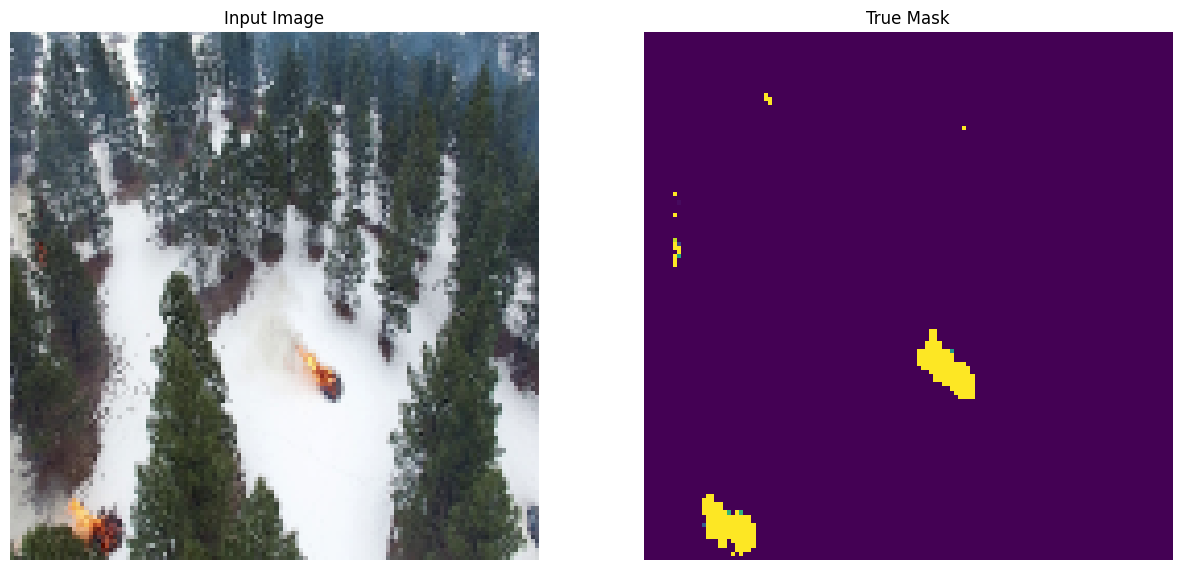

In [7]:
for images, masks in train_batches.take(1):

    sample_image = images[0]
    sample_mask = masks[0]

    display([sample_image, sample_mask])

In [8]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16,3,activation='relu',padding='same'),
    keras.layers.Conv2D(16,3,activation='relu',padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.1),
    keras.layers.Conv2D(32,3,activation='relu',padding='same'),

    keras.layers.Conv2D(32,3,activation='relu',padding='same'),
    keras.layers.Dropout(0.1),
    keras.layers.UpSampling2D(),
    keras.layers.Conv2D(64,3,activation='relu',padding='same'),
    keras.layers.Conv2D(64,3,activation='relu',padding='same'),
    keras.layers.Dropout(0.2),
    keras.layers.Conv2D(3,1,activation='softmax') 
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
def create_mask(pred_mask):
  pred_mask = tf.math.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]


In [10]:
def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in dataset.take(num):
      pred_mask = model.predict(image)
      display([image[0], mask[0], create_mask(pred_mask)])
  else:
    display([sample_image, sample_mask,
             create_mask(model.predict(sample_image[tf.newaxis, ...]))])

In [11]:
EPOCHS = 20

history = model.fit(
    train_batches,
    epochs=EPOCHS,
    validation_data=test_batches
)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 30s 568ms/step - accuracy: 0.9803 - loss: 0.4742 - val_accuracy: 0.9941 - val_loss: 0.0848
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 26s 512ms/step - accuracy: 0.9940 - loss: 0.0806 - val_accuracy: 0.9941 - val_loss: 0.0689
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9940 - loss: 0.0647 - val_accuracy: 0.9941 - val_loss: 0.0495
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 539ms/step - accuracy: 0.9940 - loss: 0.0472 - val_accuracy: 0.9941 - val_loss: 0.0363
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 531ms/step - accuracy: 0.9940 - loss: 0.0367 - val_accuracy: 0.9941 - val_loss: 0.0290
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 528ms/step - accuracy: 0.9940 - loss: 0.0300 - val_accuracy: 0.9941 - val_loss: 0.0216
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 553ms/step - accuracy: 0.9945 - loss: 0.0234 - val_accuracy: 0.9959 - val_loss: 0.0176
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 556ms/step - accuracy: 0.9952 - loss: 0.0204 - val_accurac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


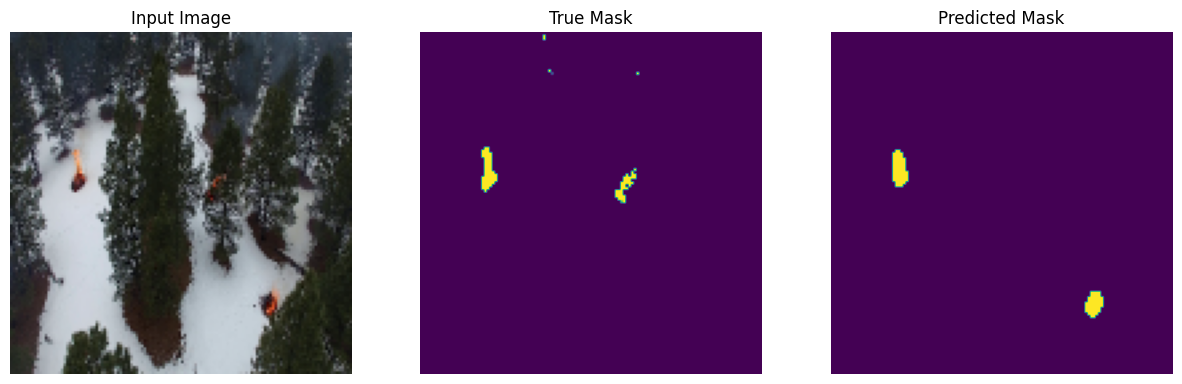

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


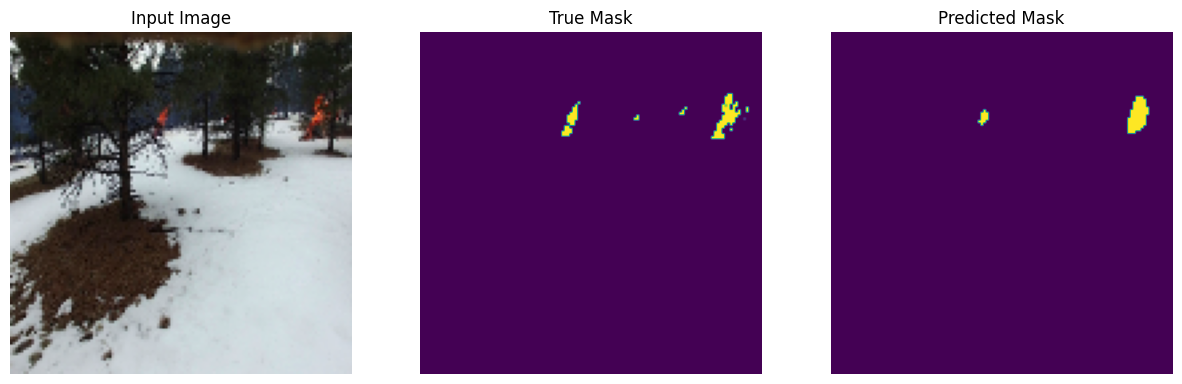

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


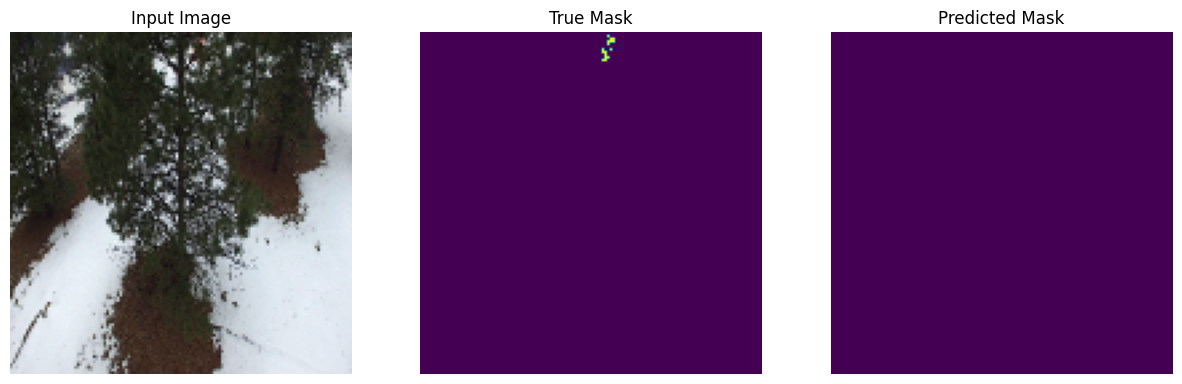

In [12]:
show_predictions(test_batches, num=3)

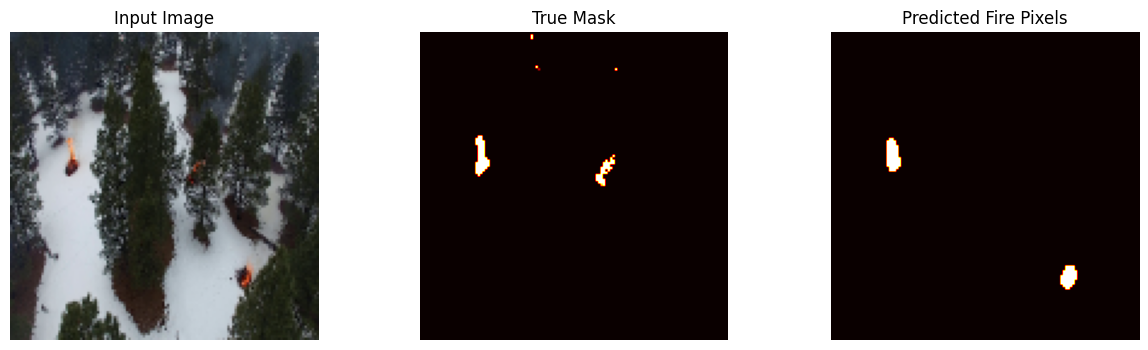

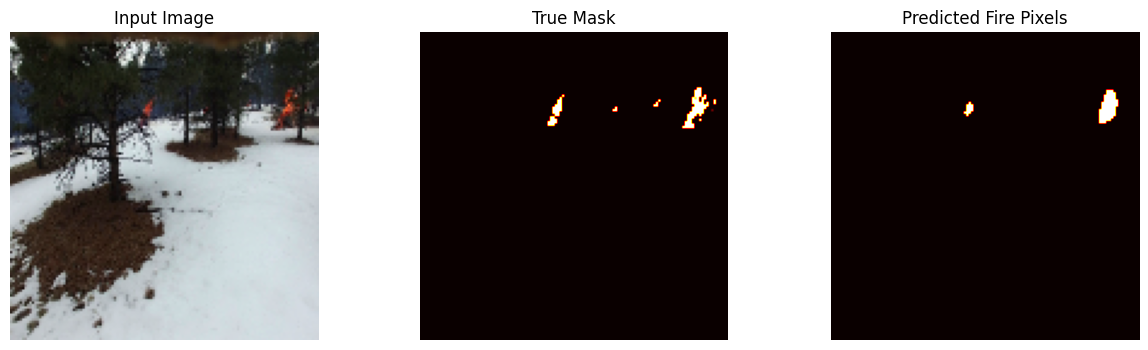

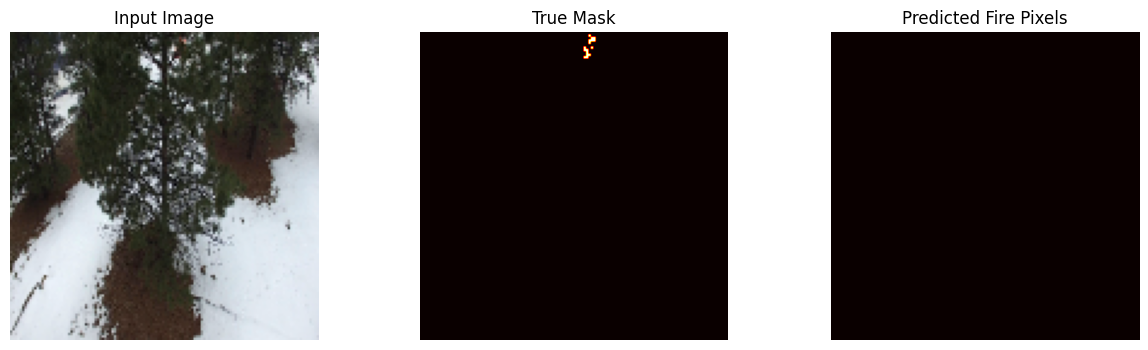

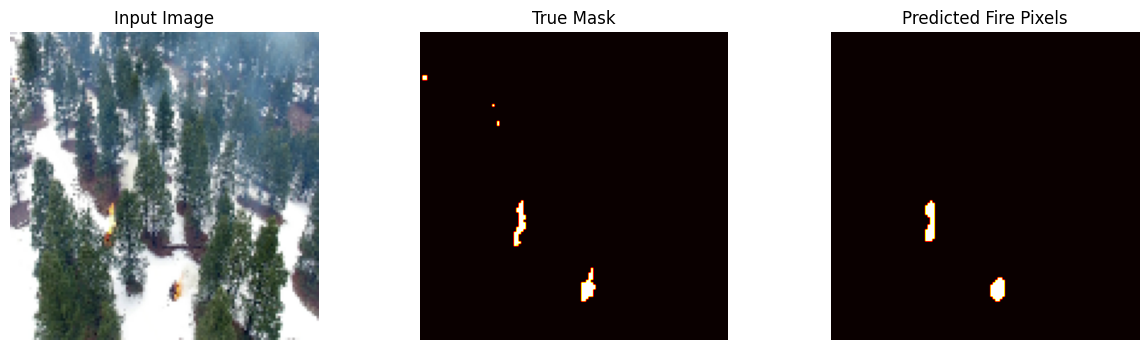

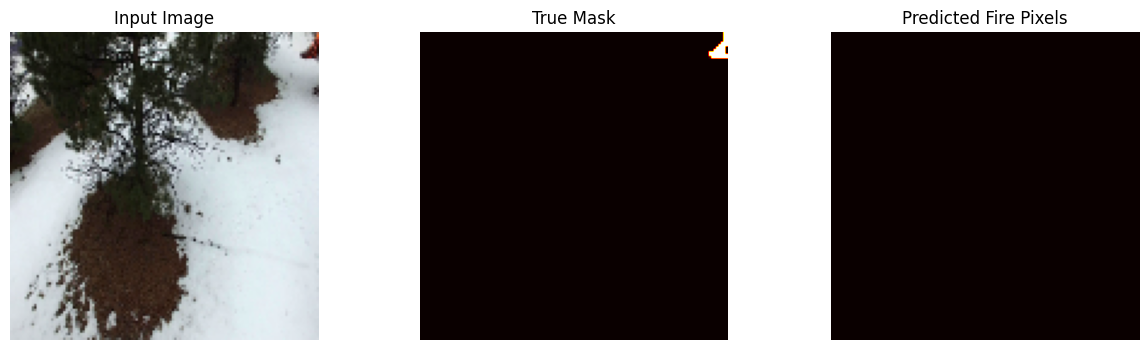

In [13]:
def predict_fire_pixels(dataset, num=5):
    for image, mask in dataset.take(num):
        image_norm = image[0]
        pred_mask = create_mask(model.predict(image, verbose=0))
        
        # fire pixels = class 1
        fire_pixels = tf.cast(pred_mask == 1, tf.float32)

        plt.figure(figsize=(15, 4))
        plt.subplot(1, 3, 1)
        plt.title("Input Image")
        plt.imshow(tf.keras.utils.array_to_img(image_norm))
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("True Mask")
        plt.imshow(tf.keras.utils.array_to_img(mask[0]), cmap='hot')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title("Predicted Fire Pixels")
        plt.imshow(tf.keras.utils.array_to_img(fire_pixels), cmap='hot')
        plt.axis('off')

        plt.show()

predict_fire_pixels(test_batches)